This model estimates the rate (λ) of discrete count data y using a log-link function, incorporating a generated quantities block to simulate new data for posterior predictive checks.stan// Save as poisson_model.stan
data {
  int<lower=0> N;          // Number of observations
  array[N] int<lower=0> y; // Count outcomes (integer array)
}

parameters {
  real log_lambda;         // Log of the rate parameter
}

model {
  // Prior
  log_lambda ~ normal(0, 5);
  
  // Likelihood
  y ~ poisson_log(log_lambda);
}

generated quantities {
  real lambda = exp(log_lambda); // Transform back to original rate scale
  array[N] int yrep;             // Replicated data for model diagnostics
  
  for (i in 1:N) {
    yrep[i] = poisson_log_rng(log_lambda);
  }
}

In [6]:
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import poisson

In [2]:
tfd = tfp.distributions
tfb = tfp.bijectors

In [11]:
# 1. Set seed for reproducibility
np.random.seed(42)

# 2. Define true underlying parameters
N = 1000                 # Number of observations
true_lambda = 4.5      # True event rate (our goal is for Stan to recover this)

# 3. Simulate Poisson count data
y_simulated = np.random.poisson(lam=true_lambda, size=N)

# 4. Package data into a dictionary for Stan
stan_data = {
    "N": N,
    "y": y_simulated.tolist()  # Stan expects a standard list/array syntax
}

# Preview the generated data structure
print("Stan Data Dictionary:")
print(stan_data)

Stan Data Dictionary:
{'N': 1000, 'y': [5, 4, 4, 5, 4, 3, 1, 6, 2, 6, 7, 2, 5, 4, 0, 5, 4, 6, 7, 1, 5, 3, 6, 6, 3, 3, 8, 3, 3, 5, 7, 3, 3, 4, 4, 7, 5, 6, 2, 2, 4, 7, 2, 8, 3, 6, 8, 5, 8, 11, 3, 2, 2, 2, 3, 2, 8, 2, 5, 7, 5, 1, 4, 4, 3, 5, 2, 9, 2, 1, 4, 5, 7, 8, 6, 6, 7, 3, 3, 3, 4, 4, 6, 4, 2, 6, 3, 5, 9, 6, 3, 7, 8, 1, 8, 2, 10, 6, 9, 3, 2, 6, 7, 6, 1, 2, 6, 1, 2, 1, 5, 5, 4, 6, 5, 4, 1, 2, 6, 4, 6, 2, 2, 3, 7, 5, 4, 3, 4, 2, 7, 6, 3, 4, 4, 6, 5, 6, 6, 3, 6, 3, 6, 5, 5, 9, 7, 5, 2, 5, 4, 5, 1, 4, 4, 4, 2, 4, 3, 6, 3, 3, 3, 2, 6, 2, 1, 6, 5, 6, 3, 4, 5, 4, 3, 6, 4, 2, 4, 7, 1, 3, 3, 8, 4, 8, 6, 5, 10, 3, 4, 6, 2, 10, 6, 3, 1, 7, 7, 5, 4, 8, 5, 3, 7, 4, 3, 7, 11, 4, 6, 6, 6, 4, 3, 2, 6, 1, 7, 4, 5, 6, 3, 8, 4, 5, 4, 5, 3, 4, 4, 4, 3, 1, 5, 3, 2, 7, 7, 2, 5, 8, 2, 6, 4, 7, 5, 5, 6, 4, 5, 2, 5, 3, 8, 2, 2, 4, 3, 7, 1, 4, 8, 3, 7, 5, 10, 3, 5, 3, 7, 1, 9, 1, 4, 4, 5, 3, 4, 4, 5, 5, 7, 4, 4, 2, 6, 6, 4, 3, 2, 3, 8, 4, 5, 7, 7, 5, 3, 6, 6, 7, 5, 7, 3, 1, 5, 4, 3, 4, 4, 3, 7, 3, 5, 2, 4, 1, 

In [12]:
# 2. Calculate theoretical Probability Mass Function (PMF)
k_values = np.arange(0, poisson.ppf(0.999, true_lambda) + 1)
theoretical_pmf = poisson.pmf(k_values, true_lambda)

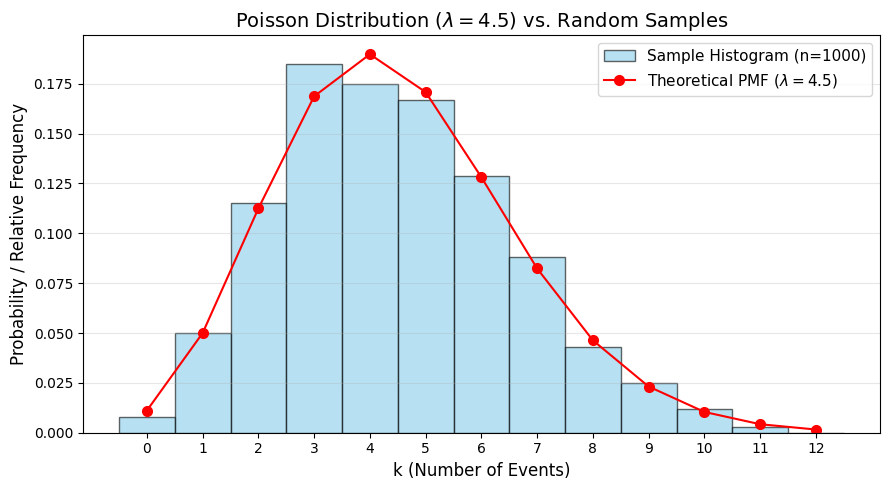

In [13]:
# 3. Create the plot
plt.figure(figsize=(9, 5))

# Normalized histogram of empirical samples
plt.hist(
    y_simulated, 
    bins=np.arange(-0.5, max(k_values) + 1.5, 1), 
    density=True, 
    alpha=0.6, 
    color='skyblue', 
    edgecolor='black', 
    label='Sample Histogram (n=1000)'
)

# Line plot for theoretical PMF
plt.plot(k_values, theoretical_pmf, 'ro-', ms=7, label=f'Theoretical PMF ($\lambda={true_lambda}$)')

# Aesthetics
plt.title(f'Poisson Distribution ($\lambda={true_lambda}$) vs. Random Samples', fontsize=14)
plt.xlabel('k (Number of Events)', fontsize=12)
plt.ylabel('Probability / Relative Frequency', fontsize=12)
plt.xticks(np.arange(0, max(k_values) + 1))
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

In [33]:
# # 2. Define the Target Log Prob function (Unnormalized Joint Posterior)
# def target_log_prob(lla):
#     # Prior distributions
#     log_lambda = tf.math.exp(tfd.Normal(loc=0.0, scale=10.0))
#     # prior_log_prob = prior.log_prob(lla)

#     # Likelihood function
#     likelihood = tfd.Poisson(rate=log_lambda)

#     likelihood_log_prob = tf.reduce_sum(likelihood.log_prob(true_lambda))

#     return log_lambda + likelihood_log_prob

In [89]:
def target_log_prob(lla):
    # 1. Prior distribution for log_lambda
    prior = tfd.Normal(loc=0.0, scale=5.0)
    prior_log_prob = prior.log_prob(lla)

    # 2. Convert log_lambda (lla) to rate lambda via exponentiation
    rate = tf.math.exp(lla)

    # 3. Likelihood function for observed counts (e.g., true_data / observations)
    likelihood = tfd.Poisson(rate=rate)
    likelihood_log_prob = tf.reduce_sum(likelihood.log_prob(true_lambda))

    # 4. Joint log probability = log prior + log likelihood
    return prior_log_prob + likelihood_log_prob

In [90]:
num_results = 8000
num_burnin_steps = 2000

In [91]:
# Base HMC kernel
hmc_kernel = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob,
    step_size=0.05,
    num_leapfrog_steps=3
)
# Adaptive step size kernel wrapper
adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    inner_kernel=hmc_kernel,
    num_adaptation_steps=int(num_burnin_steps * 0.8)
)

In [92]:
@tf.function(autograph=False, jit_compile=True)
def run_chain():
    # Initial state for parameters [slope, intercept]
    initial_state = [tf.constant(0.0)]
    
    samples, kernel_results = tfp.mcmc.sample_chain(
        num_results=num_results,
        num_burnin_steps=num_burnin_steps,
        current_state=initial_state,
        kernel=adaptive_hmc,
        trace_fn=lambda _, pkr: pkr.inner_results.is_accepted
    )
    return samples

In [93]:
estLam = run_chain()

In [101]:
lambda_samples = tf.math.exp(estLam[0]).numpy()

In [102]:
lambda_samples

array([2.53813 , 6.432686, 6.432686, ..., 5.375468, 4.280293, 4.280293],
      dtype=float32)

In [103]:
print("Posterior Mean Lamda:", tf.reduce_mean(lambda_samples).numpy())

Posterior Mean Lamda: 4.512251


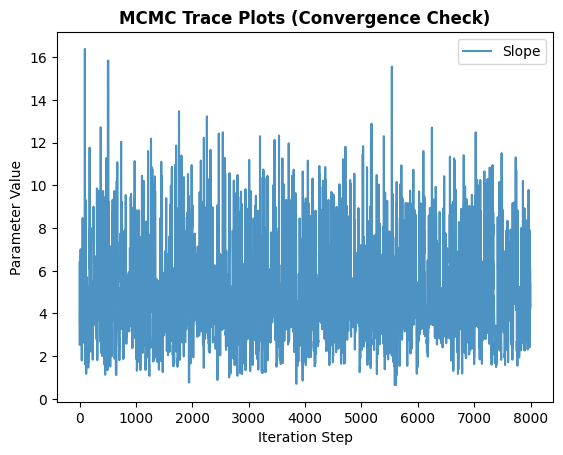

In [104]:
plt.figure()
plt.plot(2, 2, 1)
plt.plot(lambda_samples, label="Slope", alpha=0.8, color="#1f77b4")
plt.title("MCMC Trace Plots (Convergence Check)", fontsize=12, fontweight="bold")
plt.xlabel("Iteration Step")
plt.ylabel("Parameter Value")
plt.legend(loc="upper right")

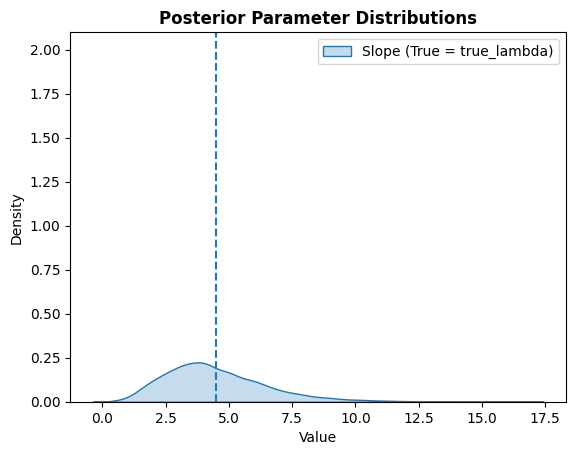

In [105]:
plt.figure()
plt.plot(2, 2, 2)
sns.kdeplot(lambda_samples, fill=True, label="Slope (True = true_lambda)", color="#1f77b4")
plt.axvline(x=true_lambda, color="#1f77b4", linestyle="--", linewidth=1.5)
plt.title("Posterior Parameter Distributions", fontsize=12, fontweight="bold")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")